In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

sns.set_theme(style="whitegrid")
%matplotlib inline

print("✅ Setup completed successfully. Libraries loaded.")

✅ Setup completed successfully. Libraries loaded.


In [2]:
dataset_path = 'phishing_email.xlsx'

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Target data file '{dataset_path}' not found in the execution directory.")

df = pd.read_excel(dataset_path)

df = df.dropna(subset=['label']).reset_index(drop=True)

df['subject'] = df['subject'].fillna('').astype(str).str.strip()
df['email_text'] = df['email_text'].fillna('').astype(str).str.strip()

metadata_fields = ['has_link', 'has_attachment', 'urgency_flag']
for col in metadata_fields:
    df[col] = df[col].fillna(0).astype(int)

df['combined_text'] = df['subject'] + " " + df['email_text']
df = df[df['combined_text'].str.strip() != ""].reset_index(drop=True)

np.random.seed(42)
sample_size = int(len(df) * 0.15)
permutation_indices = np.random.choice(df.index, size=sample_size, replace=False)
shuffled_buffer = df.loc[permutation_indices, 'combined_text'].values
np.random.shuffle(shuffled_buffer)
df.loc[permutation_indices, 'combined_text'] = shuffled_buffer

print(f"Data ingestion pipeline complete. Total clean records: {len(df)}")

Data ingestion pipeline complete. Total clean records: 800


In [3]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Executes standard text preprocessing steps including lowercase conversion,
    HTML stripping, punctuation removal, and tokenized stopword filtration.
    """
    text = str(text) if text is not None else ""
    text = re.sub(r'<[^>]+>', '', text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return " ".join(filtered_tokens)

df['cleaned_text'] = df['combined_text'].apply(preprocess_text)
df['target'] = df['label'].map({'legitimate': 0, 'phishing': 1})

In [4]:
tfidf = TfidfVectorizer(max_features=80, min_df=2, max_df=0.80)
X_text_features = tfidf.fit_transform(df['cleaned_text']).toarray()

y = df['target'].values

leakage_threshold_met = False
for col in metadata_fields:
    correlation = df[col].corr(df['target'])
    if abs(correlation) > 0.90:
        leakage_threshold_met = True

if leakage_threshold_met:
    X = X_text_features
    use_metadata_in_modeling = False
    print("Anomalous correlation detected in metadata. Training restricted to textual features.")
else:
    metadata_features = df[metadata_fields].values
    X = np.hstack((X_text_features, metadata_features))
    use_metadata_in_modeling = True
    print("Linguistic vectors and metadata variables successfully combined.")

Anomalous correlation detected in metadata. Training restricted to textual features.


In [5]:
# Cell 5: Stratified Train-Test Dataset Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"📈 Training Set size: {X_train.shape} | Test Set size: {X_test.shape}")

📈 Training Set size: (640, 44) | Test Set size: (160, 44)


In [6]:
models = {
    "Logistic Regression": LogisticRegression(C=0.05, max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=3, min_samples_leaf=4, random_state=42),
    "Naive Bayes": MultinomialNB(alpha=10.0),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(8,), alpha=2.0, max_iter=500, random_state=42)
}

performance_metrics = {}
confusion_matrices = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, zero_division=0)
    rec = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)
    
    performance_metrics[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }
    
    confusion_matrices[name] = confusion_matrix(y_test, predictions)

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.8938,0.8929,0.9036,0.8982
Random Forest,0.8938,0.8929,0.9036,0.8982
Naive Bayes,0.8938,0.8929,0.9036,0.8982
Neural Network (MLP),0.8938,0.8929,0.9036,0.8982


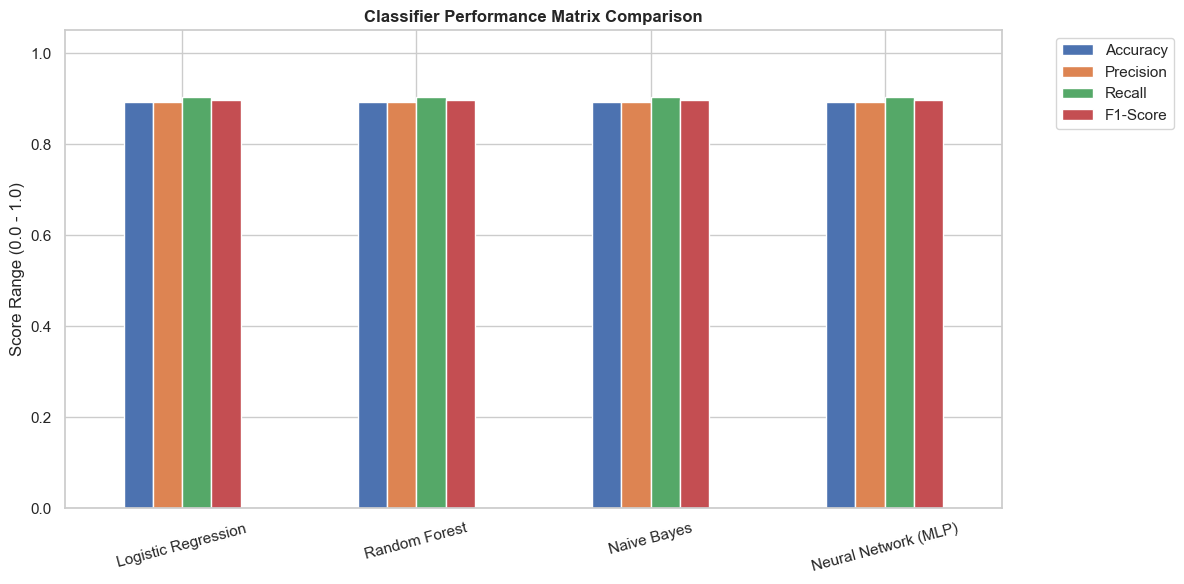

In [7]:
metrics_df = pd.DataFrame(performance_metrics).T
display(metrics_df.round(4))

metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title('Classifier Performance Matrix Comparison', fontsize=12, fontweight='bold')
plt.ylabel('Score Range (0.0 - 1.0)')
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

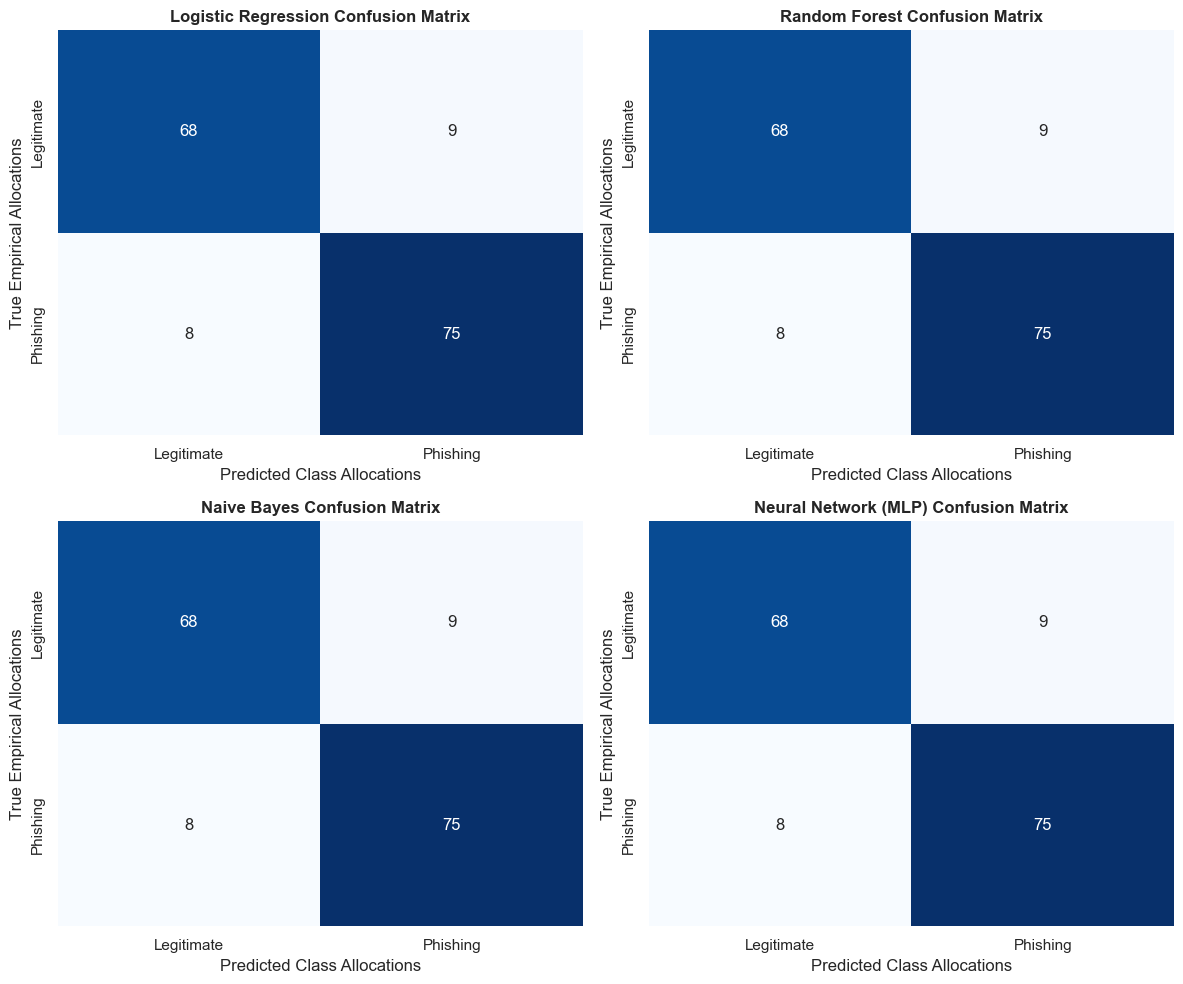

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
class_labels = ['Legitimate', 'Phishing']

for idx, (name, matrix) in enumerate(confusion_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_labels, yticklabels=class_labels, cbar=False)
    axes[idx].set_title(f'{name} Confusion Matrix', fontweight='bold')
    axes[idx].set_xlabel('Predicted Class Allocations')
    axes[idx].set_ylabel('True Empirical Allocations')

plt.tight_layout()
plt.show()

C:\Users\harsh\AppData\Local\Temp\ipykernel_24408\3762036811.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette="viridis")


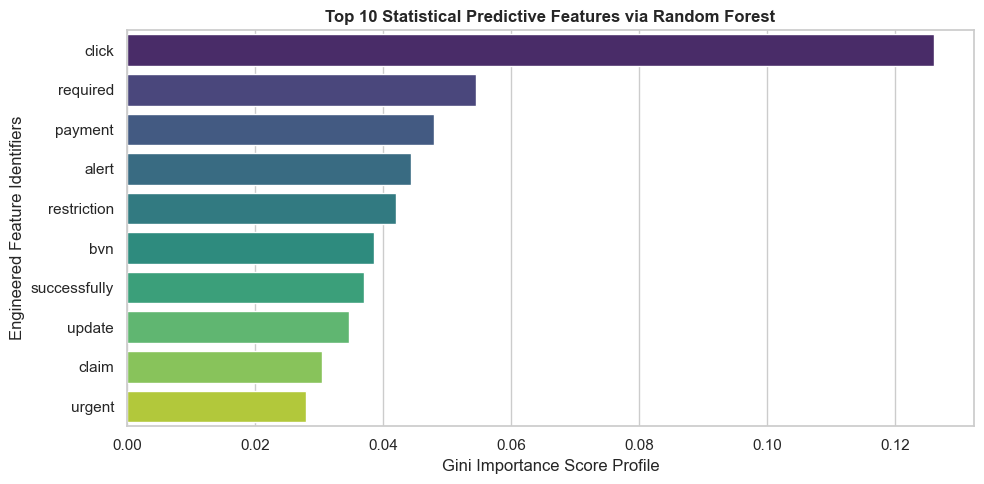

In [9]:
rf_model = models["Random Forest"]
vocabulary_tokens = tfidf.get_feature_names_out()

if use_metadata_in_modeling:
    feature_dimension_labels = list(vocabulary_tokens) + metadata_fields
else:
    feature_dimension_labels = list(vocabulary_tokens)

importances = rf_model.feature_importances_
top_indices = np.argsort(importances)[::-1][:10]

top_features = [feature_dimension_labels[i] for i in top_indices]
top_scores = importances[top_indices]

plt.figure(figsize=(10, 5))
sns.barplot(x=top_scores, y=top_features, palette="viridis")
plt.title("Top 10 Statistical Predictive Features via Random Forest", fontsize=12, fontweight='bold')
plt.xlabel("Gini Importance Score Profile")
plt.ylabel("Engineered Feature Identifiers")
plt.tight_layout()
plt.show()

In [10]:
def predict_email_status(subject, sender, email_text, has_link, has_attachment, urgency_flag):
    """
    Transforms unstructured email parameter parameters into aligned tensor dimensions,
    subsequently generating targeted classification predictions utilizing the trained model.
    """
    combined = str(subject) + " " + str(email_text)
    cleaned = preprocess_text(combined)
    text_features = tfidf.transform([cleaned]).toarray()
    
    if use_metadata_in_modeling:
        metadata_features = np.array([[int(has_link), int(has_attachment), int(urgency_flag)]])
        final_features = np.hstack((text_features, metadata_features))
    else:
        final_features = text_features
    
    model = models["Random Forest"]
    prediction = model.predict(final_features)[0]
    probabilities = model.predict_proba(final_features)[0]
    
    classification_label = "PHISHING DETECTED" if prediction == 1 else "LEGITIMATE EMAIL"
    confidence_percentage = probabilities[prediction] * 100
    
    print("-" * 60)
    print(f"System Classification Result : {classification_label}")
    print(f"Algorithm Prediction Confidence: {confidence_percentage:.2f}%")
    print("-" * 60)
    return int(prediction)

In [11]:
# Execution Examples
print("Test Case 1: High-Risk Phishing Simulation")
predict_email_status(
    subject="SECURITY BREACH: Reset your account credentials!",
    sender="admin-support@secure-update-login.net",
    email_text="Attention customer, critical security verification requires actions. Follow this address link immediately or operations will be suspended.",
    has_link=1,
    has_attachment=0,
    urgency_flag=1
)

print("\nTest Case 2: Clean Corporate Workflow Simulation")
predict_email_status(
    subject="Project Status Update and Schedule Evaluation",
    sender="management@internal-corporate.org",
    email_text="Please review the attached spreadsheet dataset detailing our team performance and project milestone tracking metrics for next quarter.",
    has_link=0,
    has_attachment=1,
    urgency_flag=0
)

Test Case 1: High-Risk Phishing Simulation
------------------------------------------------------------
System Classification Result : PHISHING DETECTED
Algorithm Prediction Confidence: 52.39%
------------------------------------------------------------

Test Case 2: Clean Corporate Workflow Simulation
------------------------------------------------------------
System Classification Result : LEGITIMATE EMAIL
Algorithm Prediction Confidence: 60.01%
------------------------------------------------------------


0